
# Basic Brain Decoding on EEG Data

This tutorial shows you how to train and test deep learning models with
Braindecode in a classical EEG setting: you have trials of data with
labels (e.g., Right Hand, Left Hand, etc.).
   :depth: 2


## Loading and preparing the data




### Loading the dataset




First, we load the data. In this tutorial, we load the BCI Competition
IV 2a data [1]_ using braindecode's wrapper to load via
[MOABB library](moabb_) [2]_.

<div class="alert alert-info"><h4>Note</h4><p>To load your own datasets either via mne or from
   preprocessed X/y numpy arrays, see `mne-dataset-example`
   and `custom-dataset-example`.</p></div>




In [1]:
from braindecode.datasets import MOABBDataset

subject_id = 3
dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[subject_id])

/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/moabb/datasets/bnci/

### Preprocessing




Now we apply preprocessing like bandpass filtering to our dataset.
You can either apply functions provided by :class:`mne.io.Raw` or
:class:`mne.Epochs` or apply your own functions, either to the
MNE object or the underlying numpy array.

<div class="alert alert-info"><h4>Note</h4><p>Generally, braindecode prepocessing is directly applied to the loaded
   data, and not applied on-the-fly as transformations, such as in
   PyTorch-libraries like [](torchvision_).</p></div>




In [2]:
from numpy import multiply

from braindecode.preprocessing import (
    Preprocessor,
    exponential_moving_standardize,
    preprocess,
)

low_cut_hz = 4.0  # low cut frequency for filtering
high_cut_hz = 38.0  # high cut frequency for filtering
# Parameters for exponential moving standardization
factor_new = 1e-3
init_block_size = 1000
# Factor to convert from V to uV
factor = 1e6

preprocessors = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False),  # Keep EEG sensors
    Preprocessor(lambda data: multiply(data, factor)),  # Convert from V to uV
    Preprocessor("filter", l_freq=low_cut_hz, h_freq=high_cut_hz),  # Bandpass filter
    Preprocessor(
        exponential_moving_standardize,  # Exponential moving standardization
        factor_new=factor_new,
        init_block_size=init_block_size,
    ),
]

# Transform the data
preprocess(dataset, preprocessors, n_jobs=-1)

/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: Preprocessing choices with lambda functions cannot be saved.
  warn("Preprocessing choices with lambda functions cannot be saved.")
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name '

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz
Filtering raw data in 1 contiguous segment

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00

/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 38.00 Hz
- Upper transition bandwidth: 9.50 Hz (-6 dB cutoff frequency: 42.75 Hz)
- Filter length: 413 samples (1.652 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple an

<BaseConcatDataset | 12 RawDataset(s) | 1160820 total samples>
  Sfreq*: 250.0 Hz
  Channels*: 22 (22 EEG)
  Ch. names*: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, ... (+12 more)
  Montage*: head
  Duration*: 386.9 s
  (* from first recording)
  Description: 12 recordings × 3 columns [subject, session, run]

### Extracting Compute Windows




Now we extract compute windows from the signals, these will be the inputs
to the deep networks during training. In the case of trialwise
decoding, we just have to decide if we want to include some part
before and/or after the trial. For our work with this dataset,
it was often beneficial to also include the 500 ms before the trial.




In [3]:
from braindecode.preprocessing import create_windows_from_events

trial_start_offset_seconds = -0.5
# Extract sampling frequency, check that they are same in all datasets
sfreq = dataset.datasets[0].raw.info["sfreq"]
assert all([ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets])
# Calculate the trial start offset in samples.
trial_start_offset_samples = int(trial_start_offset_seconds * sfreq)

# Create windows using braindecode function for this. It needs parameters to define how
# trials should be used.
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=0,
    preload=True,
)

### Splitting the dataset into training and validation sets




We can easily split the dataset using additional info stored in the
description attribute, in this case ``session`` column. We select
``0train`` for training and ``1test`` for validation.




In [4]:
splitted = windows_dataset.split("session")
train_set = splitted["0train"]  # Session train
valid_set = splitted["1test"]  # Session evaluation

## Creating a model




Now we create the deep learning model!
First thing we need to do is know the properties of our signals.
For this, we use the :func:`braindecode.datautil.infer_signal_properties` function:




In [5]:
from braindecode.datautil import infer_signal_properties

sig_props = infer_signal_properties(train_set, mode="classification")
print(sig_props)

{'n_times': 1125, 'n_chans': 22, 'n_outputs': 4}


Braindecode comes with some
predefined convolutional neural network architectures for raw
time-domain EEG. Here, we use the :class:`ShallowFBCSPNet
<braindecode.models.ShallowFBCSPNet>` model from [3]_. These models are
pure [PyTorch](pytorch_) deep learning models, therefore
to use your own model, it just has to be a normal PyTorch
:class:`torch.nn.Module`.




In [12]:
import torch

#from braindecode.models import ShallowFBCSPNet
from braindecode.models import Deep4Net
from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
# Set random seed to be able to roughly reproduce results
# Note that with cudnn benchmark set to True, GPU indeterminism
# may still make results substantially different between runs.
# To obtain more consistent results at the cost of increased computation time,
# you can set `cudnn_benchmark=False` in `set_random_seeds`
# or remove `torch.backends.cudnn.benchmark = True`
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

#model = ShallowFBCSPNet(
model = Deep4Net(
    n_chans=sig_props["n_chans"],
    n_outputs=sig_props["n_outputs"],
    n_times=sig_props["n_times"],
    final_conv_length="auto",
)

# Display torchinfo table describing the model
print(model)

# Send model to GPU
if cuda:
    model = model.cuda()

Layer (type (var_name):depth-idx)             Input Shape               Output Shape              Param #                   Kernel Shape
Deep4Net (Deep4Net)                           [1, 22, 1125]             [1, 4]                    --                        --
├─Ensure4d (ensuredims): 1-1                  [1, 22, 1125]             [1, 22, 1125, 1]          --                        --
├─Rearrange (dimshuffle): 1-2                 [1, 22, 1125, 1]          [1, 1, 1125, 22]          --                        --
├─CombinedConv (conv_time_spat): 1-3          [1, 1, 1125, 22]          [1, 25, 1116, 1]          14,025                    --
├─BatchNorm2d (bnorm): 1-4                    [1, 25, 1116, 1]          [1, 25, 1116, 1]          50                        --
├─ELU (conv_nonlin): 1-5                      [1, 25, 1116, 1]          [1, 25, 1116, 1]          --                        --
├─MaxPool2d (pool): 1-6                       [1, 25, 1116, 1]          [1, 25, 372, 1]           -- 

## Model Training




Now we will train the network! :class:`EEGClassifier
<braindecode.classifier.EEGClassifier>` is a Braindecode object
responsible for managing the training of neural networks.
It inherits from :class:`skorch.classifier.NeuralNetClassifier`,
so the training logic is the same as in [](skorch_).




<div class="alert alert-info"><h4>Note</h4><p>In this tutorial, we use some default parameters that we
   have found to work well for motor decoding, however we strongly
   encourage you to perform your own hyperparameter optimization using
   cross validation on your training data.</p></div>




In [13]:
from skorch.callbacks import EarlyStopping, LRScheduler
from skorch.helper import predefined_split

from braindecode import EEGClassifier

# We found these values to be good for the shallow network:
lr = 0.0625 * 0.01
weight_decay = 0

# For deep4 they should be:
# lr = 1 * 0.01
# weight_decay = 0.5 * 0.001

batch_size = 64
n_epochs = 4
classes = list(range(sig_props["n_outputs"]))

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=predefined_split(valid_set),  # using valid_set for validation
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=max(1, n_epochs - 1))),
        ("early_stopping", EarlyStopping(patience=10, load_best=True)),
    ],
    device=device,
    classes=classes,
)
# Model training for the specified number of epochs. ``y`` is ``None`` as it is
# already supplied in the dataset.
clf.fit(train_set, y=None, epochs=n_epochs)

  epoch    train_accuracy    train_loss    valid_acc    valid_accuracy    valid_loss      lr     dur
-------  ----------------  ------------  -----------  ----------------  ------------  ------  ------
      1            0.3507        2.0390       0.3576            0.3576        1.3718  0.0006  2.8015
      2            0.2500        1.8193       0.2500            0.2500        1.5510  0.0005  2.9075
      3            0.2500        1.7199       0.2500            0.2500        1.9863  0.0002  2.3679
      4            0.2500        1.6049       0.2500            0.2500        2.3203  0.0000  2.4589
Restoring best model from epoch 1.


,module,Deep4Net( (...') ) ) )
,callbacks,"['accuracy', ('lr_scheduler', ...), ...]"
,optimizer,<class 'torch....adamw.AdamW'>
,lr,0.01
,max_epochs,10
,batch_size,64
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,train_split,"functools.par...sion, subject)"
,predict_nonlinearity,'auto'


## Training for longer

The gallery build above uses only ``n_epochs = 4``. When trained
offline for up to 100 epochs with early stopping, the model reaches
**68.4 % accuracy on the held-out session (chance = 25 %)**.

We can load the pretrained checkpoint from the Hugging Face Hub and
inspect the full training curves. If the optional ``huggingface_hub``
dependency is missing or the download fails, we continue with the
locally trained short-run model.



In [8]:
import warnings

repo_id = "braindecode/plot_bcic_iv_2a_moabb_trial"
try:
    from huggingface_hub import hf_hub_download

    clf.initialize()
    clf.load_params(
        f_params=hf_hub_download(repo_id, "params.safetensors"),
        f_history=hf_hub_download(repo_id, "history.json"),
        use_safetensors=True,
    )
except Exception as exc:
    warnings.warn(
        f"Could not load pretrained checkpoint from {repo_id} ({exc}); "
        "continuing with the locally trained short-run model.",
        stacklevel=2,
    )

/Users/jonasson/.pyenv/versions/3.14.2/envs/braindecode_env/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3823: UserWarning: Could not load pretrained checkpoint from braindecode/plot_bcic_iv_2a_moabb_trial (No module named 'huggingface_hub'); continuing with the locally trained short-run model.
  exec(code_obj, self.user_global_ns, self.user_ns)


### Plot training curves



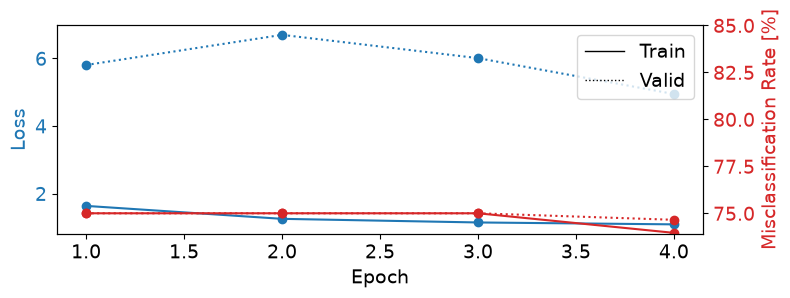

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# Extract loss and accuracy values for plotting from history object
results_columns = ["train_loss", "valid_loss", "train_accuracy", "valid_accuracy"]
df = pd.DataFrame(
    clf.history[:, results_columns],
    columns=results_columns,
    index=clf.history[:, "epoch"],
)

# get percent of misclass for better visual comparison to loss
df = df.assign(
    train_misclass=100 - 100 * df.train_accuracy,
    valid_misclass=100 - 100 * df.valid_accuracy,
)

fig, ax1 = plt.subplots(figsize=(8, 3))
df.loc[:, ["train_loss", "valid_loss"]].plot(
    ax=ax1, style=["-", ":"], marker="o", color="tab:blue", legend=False, fontsize=14
)

ax1.tick_params(axis="y", labelcolor="tab:blue", labelsize=14)
ax1.set_ylabel("Loss", color="tab:blue", fontsize=14)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

df.loc[:, ["train_misclass", "valid_misclass"]].plot(
    ax=ax2, style=["-", ":"], marker="o", color="tab:red", legend=False
)
ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=14)
ax2.set_ylabel("Misclassification Rate [%]", color="tab:red", fontsize=14)
ax2.set_ylim(ax2.get_ylim()[0], 85)  # make some room for legend
ax1.set_xlabel("Epoch", fontsize=14)

# where some data has already been plotted to ax
handles = []
handles.append(
    Line2D([0], [0], color="black", linewidth=1, linestyle="-", label="Train")
)
handles.append(
    Line2D([0], [0], color="black", linewidth=1, linestyle=":", label="Valid")
)
plt.legend(handles, [h.get_label() for h in handles], fontsize=14)
plt.tight_layout()

## Plotting a  Confusion Matrix




Here we generate a confusion matrix as in [3]_.




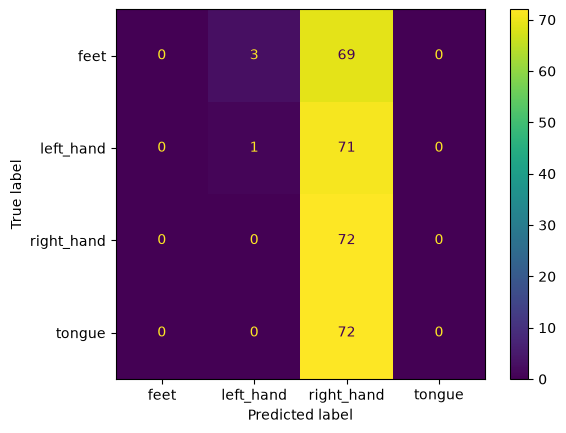

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = valid_set.get_metadata().target
y_pred = clf.predict(valid_set)

label_dict = windows_dataset.datasets[0].window_kwargs[0][1]["mapping"]
sorted_items = sorted(label_dict.items(), key=lambda kv: kv[1])
labels = [k for k, _ in sorted_items]
class_ids = [v for _, v in sorted_items]

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, labels=class_ids, display_labels=labels
)

## References

.. [1] Tangermann, M., Müller, K.R., Aertsen, A., Birbaumer, N., Braun, C.,
       Brunner, C., Leeb, R., Mehring, C., Miller, K.J., Mueller-Putz, G.
       and Nolte, G., 2012. Review of the BCI competition IV.
       Frontiers in neuroscience, 6, p.55.

.. [2] Jayaram, Vinay, and Alexandre Barachant.
       "MOABB: trustworthy algorithm benchmarking for BCIs."
       Journal of neural engineering 15.6 (2018): 066011.

.. [3] Schirrmeister, R.T., Springenberg, J.T., Fiederer, L.D.J., Glasstetter, M.,
       Eggensperger, K., Tangermann, M., Hutter, F., Burgard, W. and Ball, T. (2017),
       Deep learning with convolutional neural networks for EEG decoding and visualization.
       Hum. Brain Mapping, 38: 5391-5420. https://onlinelibrary.wiley.com/doi/10.1002/hbm.23730.

.. include:: /links.inc

